<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 4.06e-04 | train loss 0.9796 acc 0.606 | val loss 0.6847 acc 0.704 *


[ResNet-50] Epoch   2/100 | LR: 4.06e-04 | train loss 0.7392 acc 0.729 | val loss 0.6335 acc 0.724 *


[ResNet-50] Epoch   3/100 | LR: 4.06e-04 | train loss 0.7161 acc 0.729 | val loss 0.4845 acc 0.804 *


[ResNet-50] Epoch   4/100 | LR: 4.06e-04 | train loss 0.6162 acc 0.781 | val loss 0.4994 acc 0.768


...

[ResNet-50] Epoch  21/100 | LR: 4.06e-04 | train loss 0.2036 acc 0.929 | val loss 0.6032 acc 0.815


[ResNet-50] Epoch  22/100 | LR: 4.06e-04 | train loss 0.1775 acc 0.937 | val loss 0.6153 acc 0.862


[ResNet-50] Epoch  23/100 | LR: 4.06e-05 | train loss 0.2211 acc 0.927 | val loss 0.6187 acc 0.783


[ResNet-50] Epoch  24/100 | LR: 4.06e-05 | train loss 0.1908 acc 0.936 | val loss 0.3998 acc 0.848


[ResNet-50] Epoch  25/100 | LR: 4.06e-05 | train loss 0.1043 acc 0.966 | val loss 0.4228 acc 0.850

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 25.

[ResNet-50] Restored best checkpoint (val loss = 0.3627)


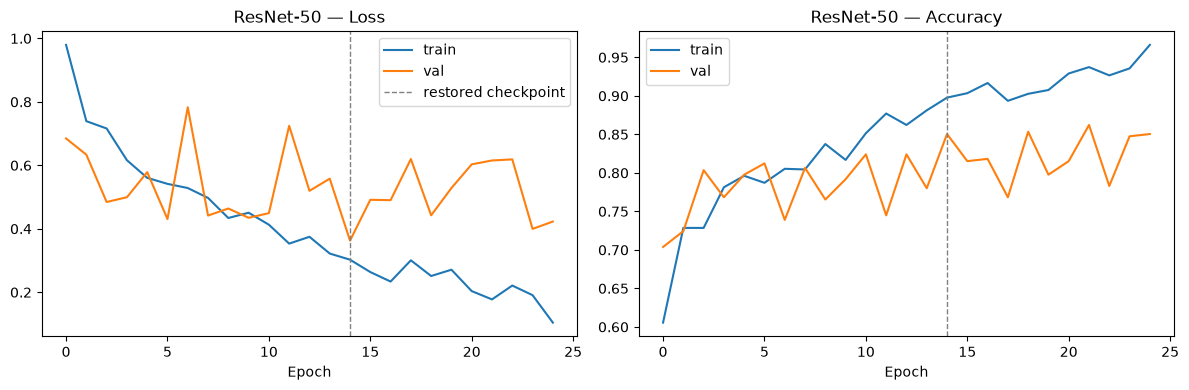

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.811


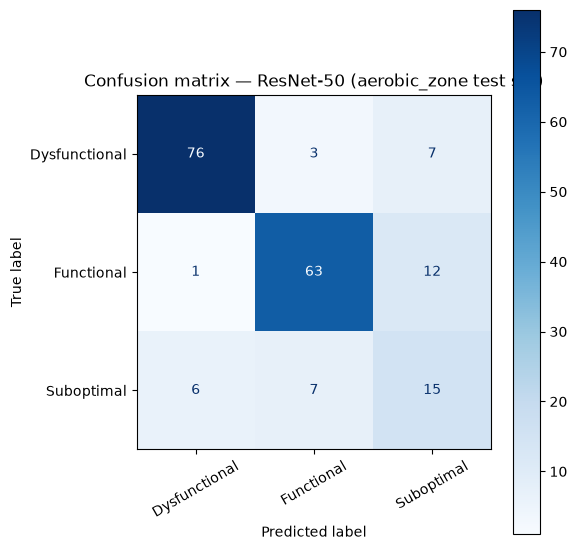

               precision    recall  f1-score   support

Dysfunctional      0.916     0.884     0.899        86
   Functional      0.863     0.829     0.846        76
   Suboptimal      0.441     0.536     0.484        28

     accuracy                          0.811       190
    macro avg      0.740     0.749     0.743       190
 weighted avg      0.825     0.811     0.817       190



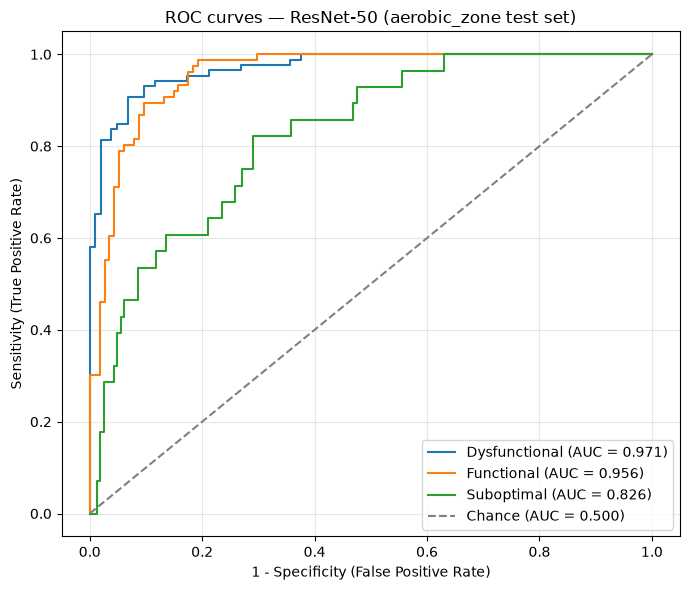

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.971
  Functional     : 0.956
  Suboptimal     : 0.826

Mean AUC (over 3/3 classes with test examples): 0.918


(np.float64(0.8105263157894737),
 {'Dysfunctional': 0.9711538461538461,
  'Functional': 0.9559095106186519,
  'Suboptimal': 0.8256172839506173})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_resnet50_stratified.pkl
Saved model weights to ../models/aerobic_zone_resnet50_cnn.pt
